In [7]:
## Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

from astroquery.jplhorizons import Horizons

In [95]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plotStack(data_stack, cadence):
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(10, 10))
    
    im = ax.imshow(data_stack[:,:,0], origin='lower')
    plt.text(0, 0, str(cadence),
             transform=plt.gca().transAxes, fontsize=12, va='bottom', ha='left',c='white')
    plt.grid(color='white')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    cbar = fig.colorbar(im, ax=ax, cax=cax, label='Relative flux (e/s)')
    
        # set plot features
    ax.set_ylim(0, len(data_stack))
    ax.set_xlim(0, len(data_stack))

    ax.set_xticks(np.arange(0, len(data_stack)+1, 10.0))
    # ax.set_yticks([])

    plt.tight_layout()
    
    im.set_data(data_stack[:,:,cadence])
        #vmin = np.min(data_stack[:,:,n])
    vmin = np.percentile(data_stack[:,:,cadence], 4)
    vmax = np.percentile(data_stack[:,:,cadence], 99.9)
        #im0.set_clim(vmin0, vmax0)
    im.set_clim(vmin, vmax)
    #t = Time(times[cadence], format='jd').iso
    #time_text.set_text(t)
    plt.show()

In [1]:
def makeEphemeris(start, stop, cadence, id):
    eph_cols = ['targetname', 'datetime_str', 'datetime_jd', 'RA', 'DEC']

    sector = Horizons(id, epochs={'start':start, 'stop':stop, 'step':cadence})
    ephemeris = sector.ephemerides()
    df = ephemeris.to_pandas()[eph_cols]
    
    return df

In [7]:
#makes a cutout of the file

def makeCutout(fits_file, position, cutout_size, output_file, hdu_num):
    # Load the image and WCS information
    with fits.open(fits_file, mode='readonly') as hdulist:
        #wcs_info = WCS(hdulist[hdu_num].header, relax=True)
        cal_image = hdulist[hdu_num].data
        header = hdulist[hdu_num].header
        
    # Convert the RA and Dec coordinates to pixel coordinates
    #position = wcs_info.world_to_pixel_values(ra, dec)

    # Create the cutout
    cutout = Cutout2D(cal_image, position, cutout_size) #, wcs=wcs_info

    # Update the header with the cutout WCS information
    #cutout_header = cutout.wcs.to_header()
    new_header = header.copy()
    #new_header.update(cutout_header)
        
    # Create a PrimaryHDU object with the cutout data and the updated header
    hdu = fits.PrimaryHDU(data=cutout.data, header=new_header)
    hdulist_new = fits.HDUList([hdu])

    # Write the cutout to a new FITS file
    hdulist_new.writeto(output_file, overwrite=True)


In [5]:
#convert between TESS time and irl time

from astropy.time import Time
def BTJDtoUTC(btjd):
    bjd = btjd + 2457000.0  # BTJD is BJD - 2457000.0
    time_bjd = Time(bjd, format='jd', scale='tdb')
    time_utc = time_bjd.utc.iso
    return time_utc

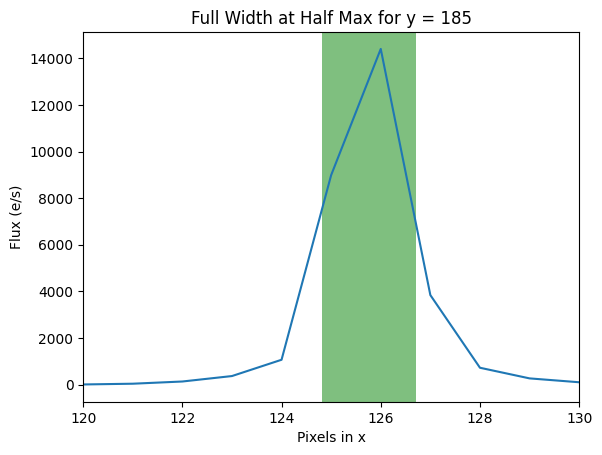

Roots: (124.81941484599535, 126.7009194410995)
Full Width at Half Max = 1.881504595104147
Ideal aperture size = 3.763009190208294


In [129]:
import numpy as np
from scipy.interpolate import UnivariateSpline

y_pixel = 185
flux_at_pixel = data_stack[y_pixel, :, 0]
coord = np.arange(len(flux_at_pixel))

# create a spline of x and blue-np.max(blue)/2 
spline = UnivariateSpline(coord, flux_at_pixel-np.max(flux_at_pixel)/2, s=0)
r1, r2 = spline.roots() # find the roots

import pylab as pl
pl.plot(coord, flux_at_pixel)
pl.axvspan(r1, r2, facecolor='g', alpha=0.5)
pl.xlim(120, 130)
pl.title(f"Full Width at Half Max for y = {y_pixel}")
pl.xlabel("Pixels in x")
pl.ylabel("Flux (e/s)")
pl.show()

print(f"Roots: {r1, r2}")
print(f"Full Width at Half Max = {(r2-r1)}")
print(f"Ideal aperture size = {2*(r2-r1)}")

In [11]:
#Get FWHM for aperture
from astropy.io import fits
import importlib  
from tess_stars2px import tess_stars2px_function_entry

fitfil = '/scratch11/ktp9/DIA/70/stacks/sector70.fits'
with fits.open(fitfil) as hdu:
    data_stack = hdu[2].data
    time = hdu[3].data
    first_frame = data_stack[0]
    first_time = time[0]
    last_time = time[-1]

start = str(BTJDtoUTC(first_time))
stop = str(BTJDtoUTC(last_time))
step_count = 100

object_id = "899" 

ticid = "899" #not the real ticid, just a name stand-in but must be numeric

sector = 70
camera = 1
ccd = 1

axs = 150

df = makeEphemeris(start, stop, str(step_count), object_id)
ra = df.loc[0, 'RA']
dec = df.loc[0, 'DEC']
print(ra, dec)

outID, outEclipLong, outEclipLat, outSec, outCam, outCcd, outColPix, outRowPix, \
scinfo = tess_stars2px_function_entry(ticid, ra, dec)
#print(outSec, outCam, outCcd, outColPix, outRowPix)

index = np.where(outSec == sector)[0] and np.where(outCam == camera)[0] and np.where(outCcd == ccd)[0]
#print(index)

x_ffi_px = outColPix[index]
y_ffi_px = outRowPix[index]

ra_ct_origin = df.loc[step_count/2, 'RA'] + (0.0058333*20) #sec 70 edge adjustment
dec_ct_origin = df.loc[step_count/2, 'DEC']  - (0.0058333*60) #sec70 edge adjustment
originID, originEclipLong, originEclipLat, originSec, originCam, originCcd, \
originColPix, originRowPix, originscinfo = tess_stars2px_function_entry(ticid, ra_ct_origin, dec_ct_origin)

x_ct_origin = originColPix[index] - axs/2 
y_ct_origin = originRowPix[index] - axs/2
print(x_ct_origin, y_ct_origin)

#x, y at cadence 0 (these are 1-2 px off from the max but the peaks sameish width)
x_ct_px = int(x_ffi_px[0] - x_ct_origin[0])
y_ct_px = int(y_ffi_px[0] - y_ct_origin[0])
print(x_ct_px, y_ct_px)

#RANGES FOR GUASSIANS
# px_range = range(x_ct_px - 5, x_ct_px + 5)
# py_range = range(y_ct_px - 5, y_ct_px + 5)

#PLOT GUASSIANS for x-axis
# fig, ax = plt.subplots(1, len(px_range), figsize=(30, 5))
# i = 0
# for x in px_range:
#     column_at_x = data_stack[:, x, 0]
#     #print(column_at_x.shape)
#     pixels = np.arange(len(column_at_x))
#     #print(pixels.shape)
#     ax[i].set_title(f"x = {x}")
#     ax[i].plot(column_at_x, pixels,color="black")
#     i += 1
# fig.suptitle('Frame 0: y-coord vs. Flux')
# fig.text(0.5, 0, 'Flux', ha='center')
# fig.text(0, 0.5, 'y-coordinate in pixels', va='center', rotation='vertical')
# plt.tight_layout()
# plt.show()

# PLOT GUASSIANS for y-axis
# fig, ax = plt.subplots(len(py_range), 1, figsize=(8, 32))
# i = 0    
# for y in py_range:
#     column_at_y = data_stack[y, :, 0]
#     #print(column_at_x.shape)
#     pixels = np.arange(len(column_at_y))
#     #print(pixels.shape)
#     ax[i].set_title(f"y = {y}")
#     ax[i].plot(pixels, column_at_y, color="black")
#     i += 1
# fig.suptitle('Frame 0: x-coord vs. Flux', y=1, ha='center')
# fig.text(0.5, 0, 'x-coordinate in pixels', ha='center')
# fig.text(0, 0.5, 'Flux', va='center', rotation='vertical')
# plt.tight_layout()
# plt.show()

356.74298 -2.80175
[1904.06143673] [1022.91083841]
138 9


In [56]:
import sys
np.set_printoptions(threshold=sys.maxsize)
for x in px_range:
    print(f"x = {x}")
    print(data_stack[x, 58, 0])

x = -3
0.55970764
x = -2
0.67918396
x = -1
1.0106812
x = 0
-1.3423767


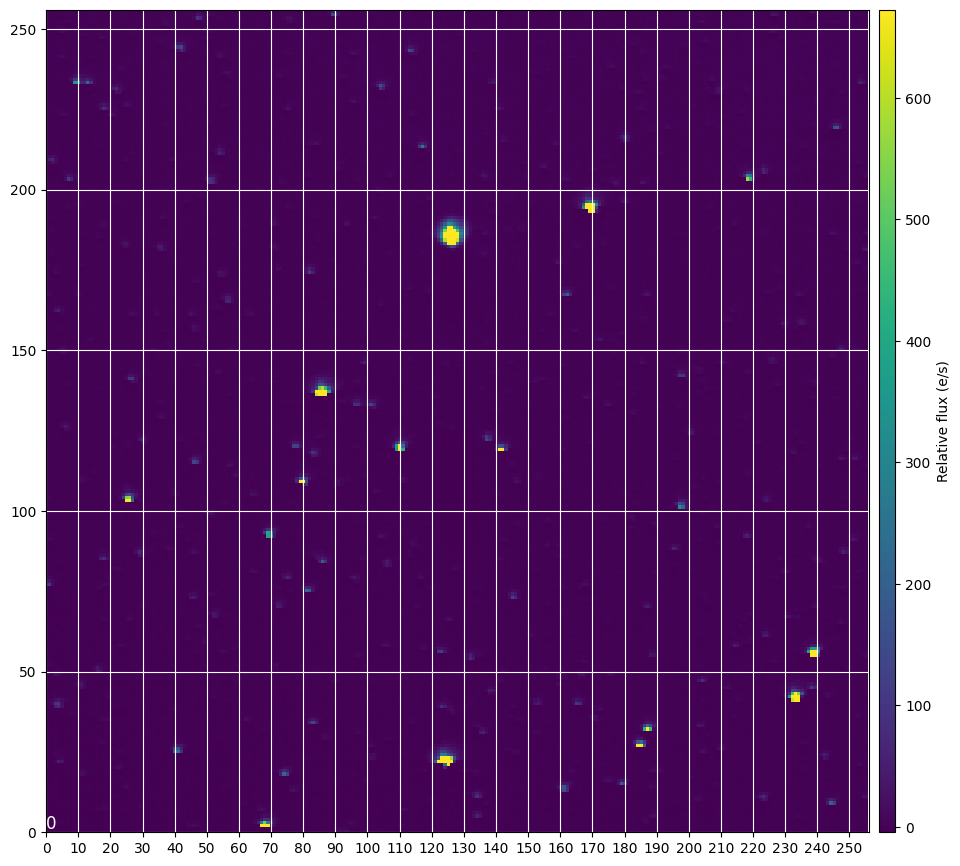

In [96]:
plotStack(data_stack, 0)

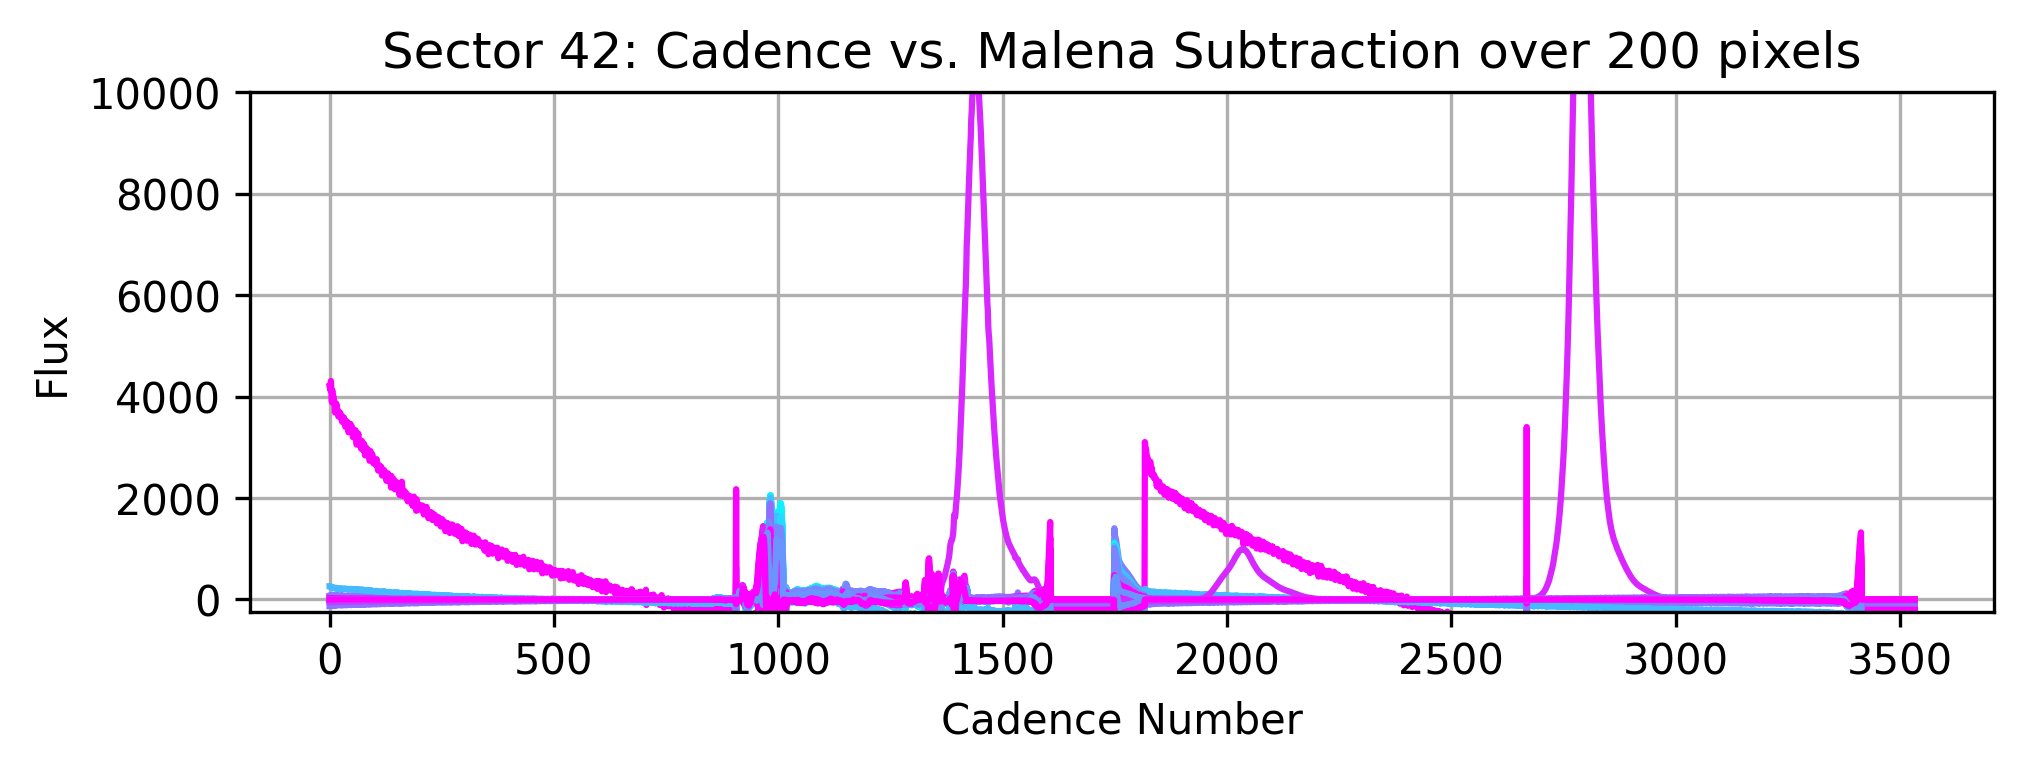

In [26]:
from astropy.io import fits
import random 
from matplotlib.colors import Normalize
from matplotlib.pyplot import get_cmap
import numpy as np
import matplotlib.pyplot as plt
import os
def scatterlc(arr, x_pixel_range, y_pixel_range):
    
    pltnum = 200 #number of lightcurves on the graph
    random_coordinates = [(random.randint(0, x_pixel_range), random.randint(0, y_pixel_range)) for _ in range(pltnum)]

    # Generate the z indices
    z_indices = np.arange(arr.shape[2])

    #normalize coords to fit colormap
    norm = Normalize(vmin=0, vmax=149)
    cmap = plt.get_cmap('cool') #get creative!

    #Plot the data
    plt.figure(figsize=(7.5, 2.25), dpi = 300)
    for ii in (range(pltnum)):
        coord = random_coordinates[ii]
        color = cmap(norm(coord[1]))
        plt.plot(z_indices, arr[coord[0], coord[1], :], color=color, linestyle = '-', marker=' ')
    
    plt.xlabel('Cadence Number')
    plt.ylabel('Flux')
    plt.ylim(-250, 10000)
    #plt.xlim(2000, 4000)
    plt.title(f'Sector 42: Cadence vs. Malena Subtraction over {pltnum} pixels')
    plt.grid(True)
    plt.show()
"""
fitdir = '/scratch11/ktp9/DIA/70/archive/'
data_fits = fitdir + 'DIA70.fits'

with fits.open(data_fits) as hdu:
    data_stack = hdu[1].data
    times = hdu[2].data
"""
data_stack = np.load('/scratch11/ktp9/DIA/42/stacks/mcleaned42.npy')
scatterlc(data_stack, 255, 255)

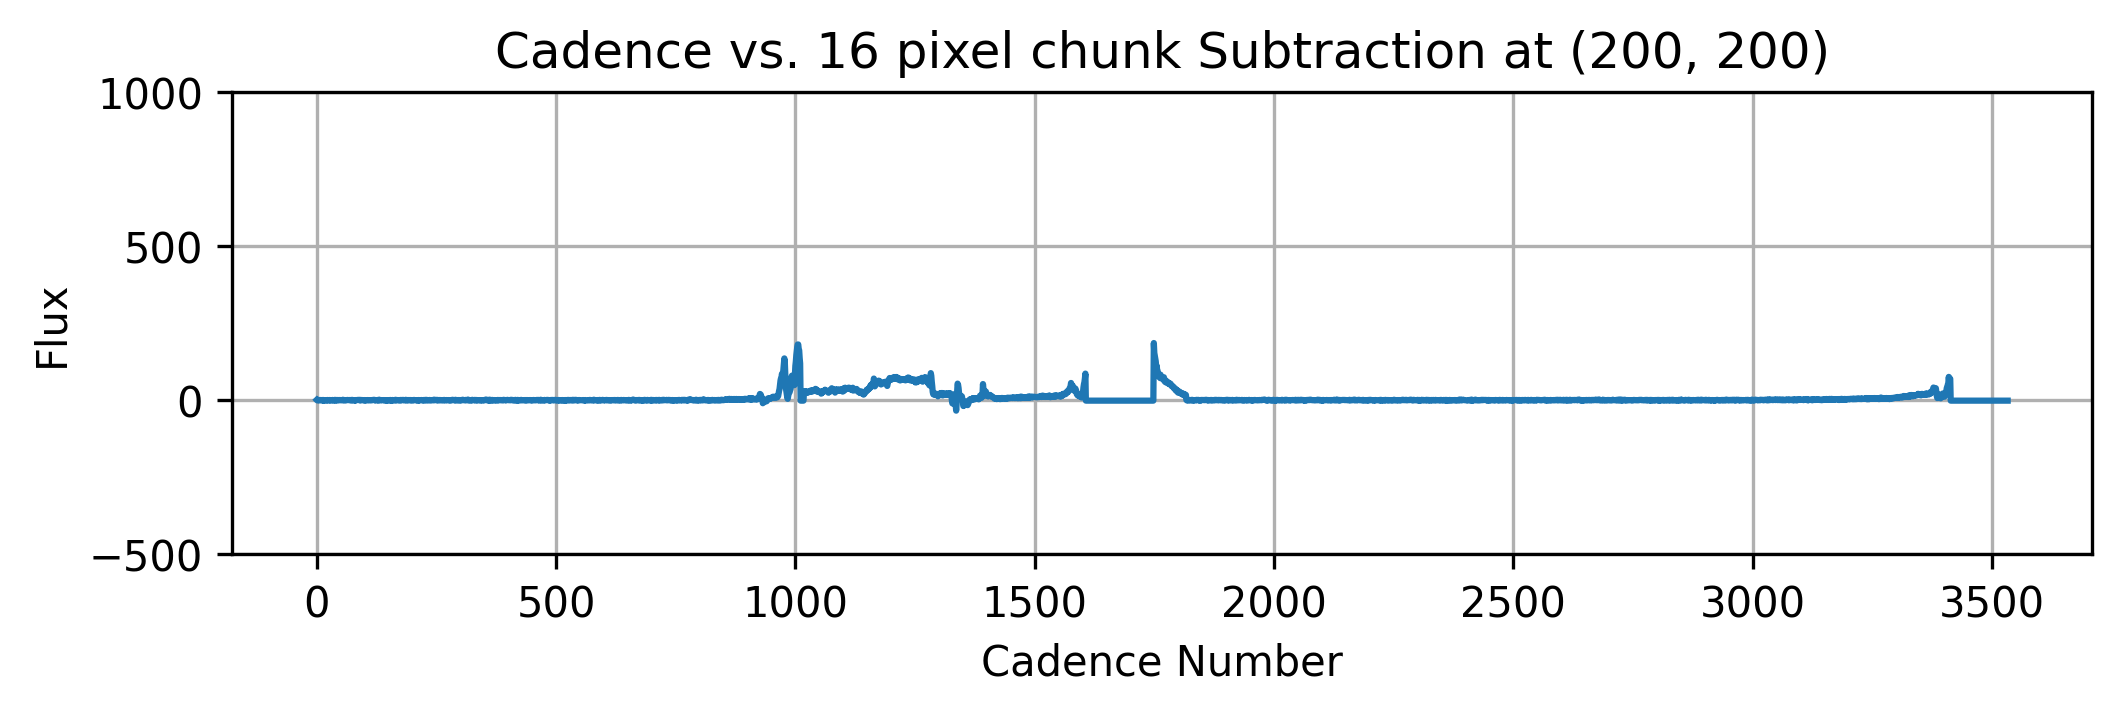

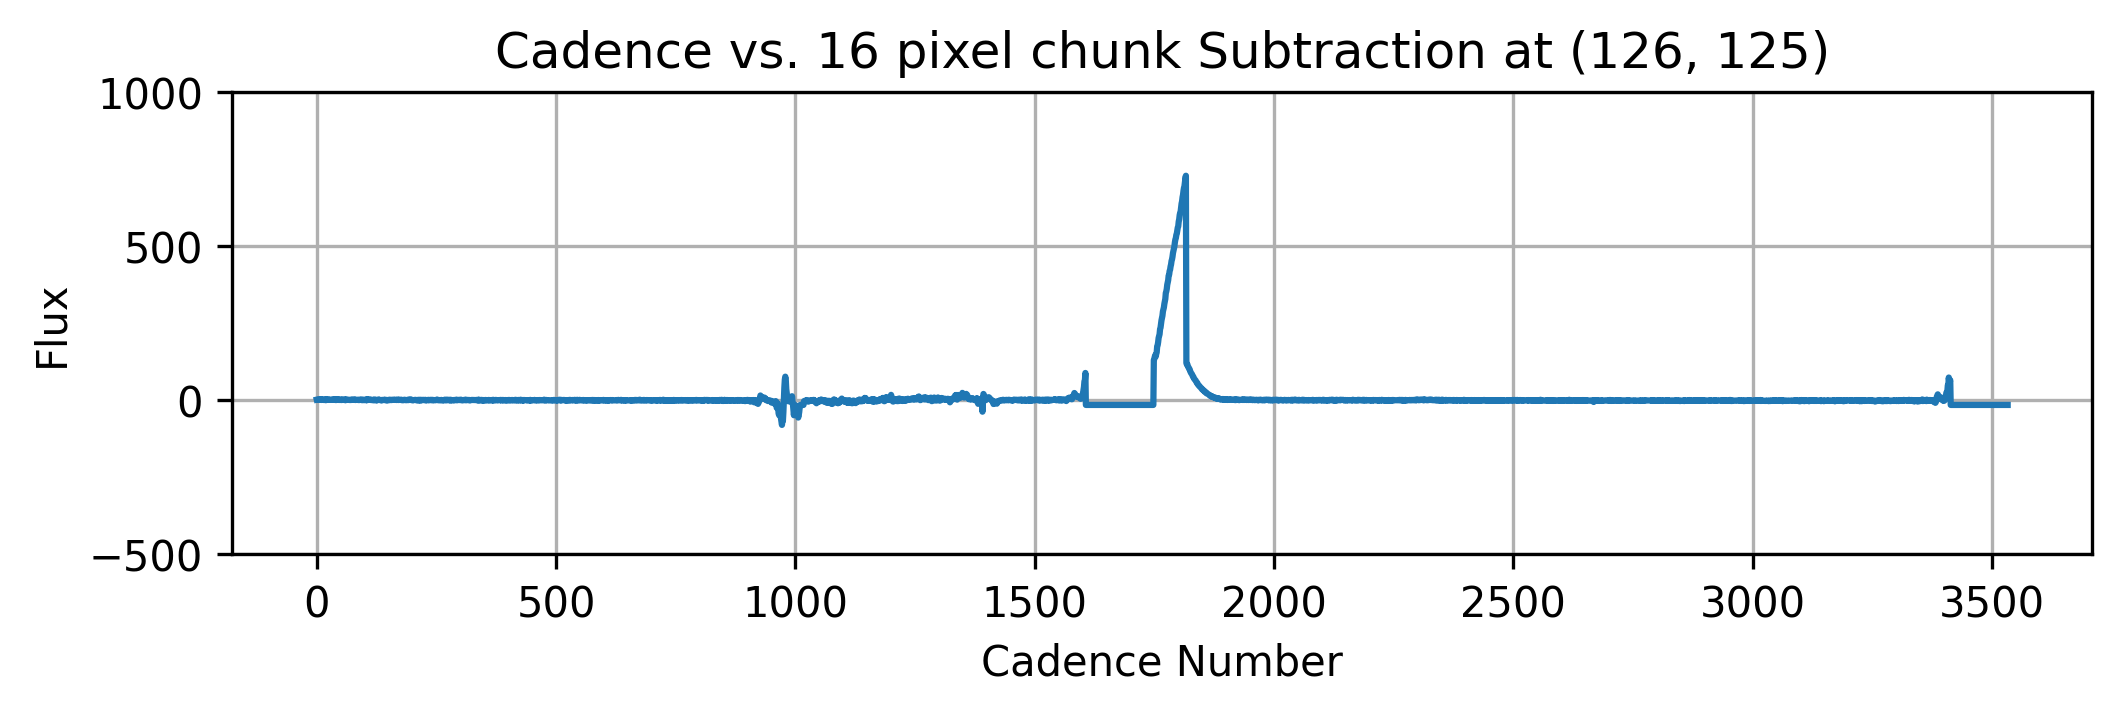

In [5]:
#diagnistic: takes random pixels and makes individual lightcurves for each
import numpy as np
import matplotlib.pyplot as plt
def linelc(arr, x, y, credit):
    
    flxxy = arr[x, y]

    # Generate the z indices
    z_indices = np.arange(flxxy.shape[0])

    #Plot the data
    plt.figure(figsize=(8, 2), dpi=300)
    plt.plot(z_indices, flxxy, linestyle='-', marker='')
    plt.xlabel('Cadence Number')
    plt.ylabel('Flux')
    plt.ylim(-500, 1000)
    #plt.xlim(2000, 4000)
    plt.title(f'Cadence vs. {credit} Subtraction at ({x}, {y})')
    plt.grid(True)
    plt.show()

m = np.load('/scratch11/ktp9/DIA/42/stacks/mcleaned42.npy')
k = np.load('/scratch11/ktp9/DIA/42/sec42chunk16.npy')

linelc(k, 200, 200, "16 pixel chunk")
linelc(k, 126, 125, "16 pixel chunk")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mklc import extract_positions, get_summed_fluxes    

data_stack = np.load('/scratch11/ktp9/DIA/42/discovery42.npy')
times = np.load('/scratch11/ktp9/DIA/42/stacks/time.npy')

startx = 127 #UPDATE
starty = 187 #UPDATE
positions_all, times_all = extract_positions(data_stack, times, startx, starty)
print(f"Shape of positions: {positions_all.shape}")
print(f"Shape of times: {times_all.shape}")
#check for useable data count
mask = ~np.isnan(positions_all)
data_count = np.sum(mask, axis=0)
print(f"Data count: {data_count}")

plt.figure(figsize = (24,10))

for r in range(4, 9): #CONSIDER updating for your radius
    summed_fluxes_all = get_summed_fluxes(data_stack, positions_all, r)
    plt.scatter(time, array, label=f"Radius = {r}", s=3)

plt.xlabel('Time (BTJD)')
plt.ylabel('Normalized Flux (e/s)')
plt.ylim(73000, 76000)
plt.xticks(np.arange(min(time), max(time)+1, 1))
plt.title('TESS Sector 42 Neptune Flux, Multiple Apertures')
plt.legend(title='Aperture Size (pixels)')  # Add a legend
plt.grid(True)
plt.show()

NameError: name 'np' is not defined

In [7]:
stars_BTJD = [2450.446285, 2461.731366, 2464.085583, 2468.648137, 2472.314699]

for time in stars_BTJD:
    print(f"time = {time} = {BTJDtoUTC(time)}")

time = 2469 = 2021-09-11 11:58:50.818
time = 2470.7 = 2021-09-13 04:46:50.818


[39421]


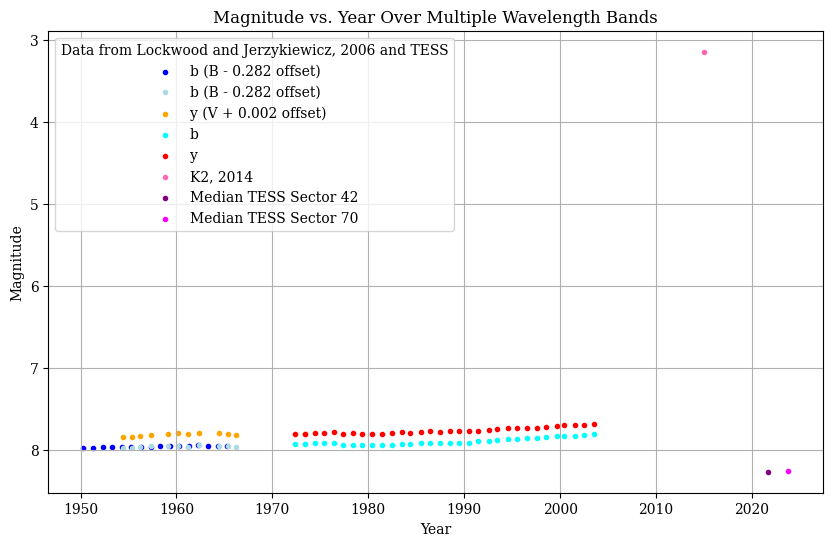

In [13]:
#data parsing
import pandas as pd

#graphing
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

#From LJ06
def tableToArray(start_row, end_row, column_index):
    selected_cells = df.iloc[start_row:end_row, column_index].to_numpy()
    selected_cells = selected_cells.astype(float)
    return selected_cells

def BTJDtoDecimalYear(time):
    years = 2000 + ((time + 2457000.0) - 2451545.0)/365.25 
    return years

def flux2Mag(flux):
    mag = -2.5*np.log10(flux) + 20.44
    return mag 
    
# Read the CSV file into a DataFrame
csv_file_path = '/scratch11/ktp9/DIA/Neptune_Data_Matrix.csv' 
df = pd.read_csv(csv_file_path)

# Access data using row and column indices with iloc
year_index_1 = 4   # year columns
year1_row_start, year1_row_end = 3, 19
year_index_2_3 = 6 
year2_row_start, year2_row_end = 24, 36
year3_row_start, year3_row_end = 44, 76

B_index_1 = 5
B_index_2 = 7
b_index_3 = 10

V_index_2 = 10
y_index_3 = 7

bminusB_col = 3
Vminusy_col = 4
correction_row = 89

years1 = tableToArray(year1_row_start, year1_row_end, year_index_1)
B_mag_1 = tableToArray(year1_row_start, year1_row_end, B_index_1)
b_mag_1 = B_mag_1 - 0.282

years2 = tableToArray(year2_row_start, year2_row_end, year_index_2_3)
B_mag_2 = tableToArray(year2_row_start, year2_row_end, B_index_2)
b_mag_2 = B_mag_2 - 0.282
V_mag_2 = tableToArray(year2_row_start, year2_row_end, V_index_2)
y_mag_2 = V_mag_2 + 0.002

years3 = tableToArray(year3_row_start, year3_row_end, year_index_2_3)
b_mag_3 = tableToArray(year3_row_start, year3_row_end, b_index_3)
y_mag_3 = tableToArray(year3_row_start, year3_row_end, y_index_3)

#TESS Data, not detrended for TESS orbit
time42 = np.load('/scratch11/ktp9/DIA/42/stacks/time_42_7_16.npy')
#np.load('/scratch11/ktp9/DIA/42/stacks/time.npy', allow_pickle=True)
#time42 = np.array(time42[0], dtype=float)
flux42 = np.load('/scratch11/ktp9/DIA/42/stacks/TESS_detrended_42_7_16.npy')

years42 = BTJDtoDecimalYear(time42)
mag42 = flux2Mag(flux42)
#print(flux42.shape, time42.shape)

#get median
median42 = np.median(mag42)
#print(median42)
tolerance42 = 1e-4
tolerance70 = 1e-5  # Adjust this value as needed

index42 = np.where(np.abs(mag42 - median42) < tolerance42)[0]#np.where(mag42 == median42)[0]
#print(index42)

time70 = np.load('/scratch11/ktp9/DIA/70/stacks/time_70_6_15.npy')
#np.load('/scratch11/ktp9/DIA/70/stacks/time.npy')
flux70 = np.load('/scratch11/ktp9/DIA/70/stacks/TESS_detrended_70_6_15.npy')
#print(flux70.shape, time70.shape)
years70 = BTJDtoDecimalYear(time70)
mag70 = flux2Mag(flux70)

median70 = np.median(mag70)

index70 = np.where(np.abs(mag70 - median70) < tolerance70)[0]

#index70 = np.where(mag70 == median70)[0]
#print(median_indices)
#print(median70)

#K2
with open('/scratch11/ktp9/DIA/phot.m2.20160224.cjp.dat', 'r') as file:
    lines = file.readlines()

# Process the lines as needed
k2 = []
for line in lines:
    # Assume space-separated values, adjust as needed
    values = line.strip().split()
    k2.append([float(v) for v in values])

k2_array = np.array(k2)
timesk2 = (k2_array[:,0]/365.25) + 2014.9164 #decimal year offset, approx
k2_corrected = np.load('/scratch11/ktp9/DIA/k2_flux_distcorrected.npy')
k2 = flux2Mag(k2_corrected)
mediank2 = np.median(k2)
indexk2 = np.where(np.abs(k2 - mediank2) < 1e-7)[0]
print(indexk2)
#print(timesk2[0])

#plot
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(10, 6))
plt.gca().invert_yaxis()

#LJ06
plt.scatter(years1, b_mag_1, label='b (B - 0.282 offset)', marker='.', color='b')

plt.scatter(years2, b_mag_2, label='b (B - 0.282 offset)', marker='.', color='lightblue')
plt.scatter(years2, V_mag_2, label='y (V + 0.002 offset)', marker='.', color='orange')

plt.scatter(years3, b_mag_3, label='b', marker='.', color='cyan')
plt.scatter(years3, y_mag_3, label='y', marker='.', color='r')

#K2
plt.scatter(timesk2[indexk2], mediank2, label='K2, 2014', marker='.', color='hotpink')

#TESS
#print(years42[index42])
#print(years70[index70])

plt.scatter(years42[index42[0]], median42, label='Median TESS Sector 42', marker='.', color='purple')
plt.scatter(years70[index70[0]], median70, label='Median TESS Sector 70', marker='.', color='magenta')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Magnitude')
#plt.ylim(8.3, 7.65)
plt.title('Magnitude vs. Year Over Multiple Wavelength Bands')
plt.legend(title='Data from Lockwood and Jerzykiewicz, 2006 and TESS') #

# Set the step size for x-axis and y-axis
x_major_locator = MultipleLocator(10)  # Set major ticks at intervals of 1 on x-axis
y_major_locator = MultipleLocator(5)  # Set major ticks at intervals of 5 on y-axis

#plt.xticks(np.arange(1950, max(years3)+1, 1))

# Show grid
plt.grid(True)

# Show the plot
plt.show()

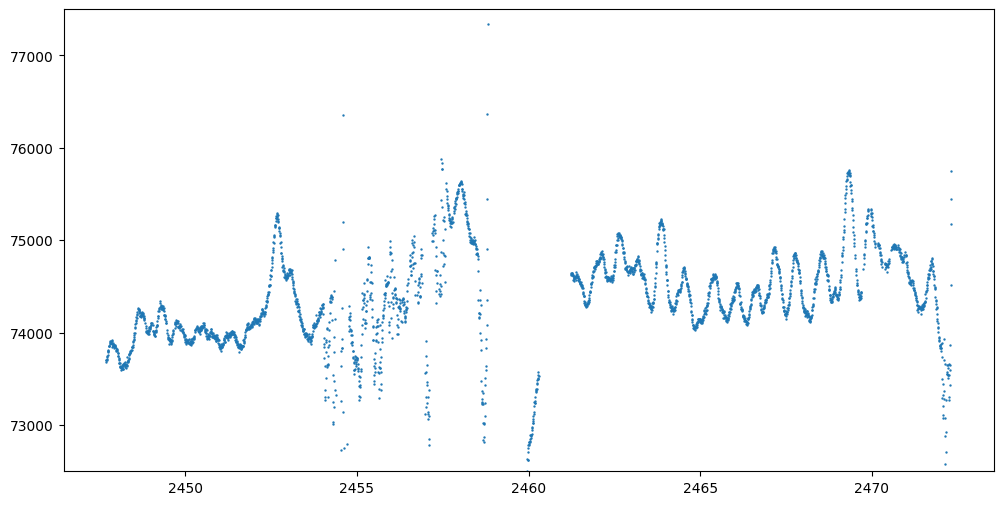

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from numpy import loadtxt
lines = loadtxt("/scratch11/ktp9/DIA/42/lcfiles/lc_Neptune_s42_cam2_ccd4_July2024.txt", comments="#", delimiter=" ", unpack=False)

jd_times = lines[0]
btjd_times = jd_times - 2457000.0
flux = lines[1]

plt.figure(figsize=(12,6))
plt.scatter(btjd_times, flux, s=0.5)
plt.ylim(72500, 77500)
plt.show()

In [9]:
import sys
import os
import numpy as np

# Add the helpers directory to the Python path
sys.path.append(os.path.abspath('/home/ktp9/TESSNeptune24/code/mklc'))

from mklc import extract_positions, get_summed_fluxes

offsets = [(-20, 0), (20, 0), (0, -20), (0, 20)]

startx_70 = 138 #42: 127 #UPDATE
starty_70 = 9 #42: 187 #UPDATE
data_stack_70 = np.load('/scratch11/ktp9/DIA/70/sec70chunk15.npy')
times_70 = np.load('/scratch11/ktp9/DIA/70/stacks/time.npy')

positions_all_70, times_all_70 = extract_positions(data_stack_70, times_70, startx_70, starty_70)

 13%|██▊                   | 1356/10730 [00:14<01:46, 87.68it/s]

Index 1341 appended with NaNs. Exception occurred.
Index 1342 appended with NaNs. Exception occurred.
Index 1343 appended with NaNs. Exception occurred.
Index 1344 appended with NaNs. Exception occurred.
Index 1345 appended with NaNs. Exception occurred.


 13%|██▊                  | 1439/10730 [00:14<01:30, 102.49it/s]

Index 1427 appended with NaNs. Exception occurred.
Index 1428 appended with NaNs. Exception occurred.
Index 1429 appended with NaNs. Exception occurred.
Index 1430 appended with NaNs. Exception occurred.
Index 1431 appended with NaNs. Exception occurred.
Index 1432 appended with NaNs. Exception occurred.
Index 1433 appended with NaNs. Exception occurred.
Index 1434 appended with NaNs. Exception occurred.


 14%|██▉                  | 1527/10730 [00:15<01:28, 103.43it/s]

...

 43%|█████████▌            | 4637/10730 [00:54<03:06, 32.58it/s]

Index 4633 appended with NaNs. Exception occurred.
Index 4634 appended with NaNs. Exception occurred.


 71%|███████████████▋      | 7654/10730 [01:24<00:31, 98.33it/s]

Index 7643 appended with NaNs. Exception occurred.


100%|█████████████████████| 10730/10730 [01:55<00:00, 92.90it/s]


100%|███████████████████| 10730/10730 [00:10<00:00, 1045.70it/s]


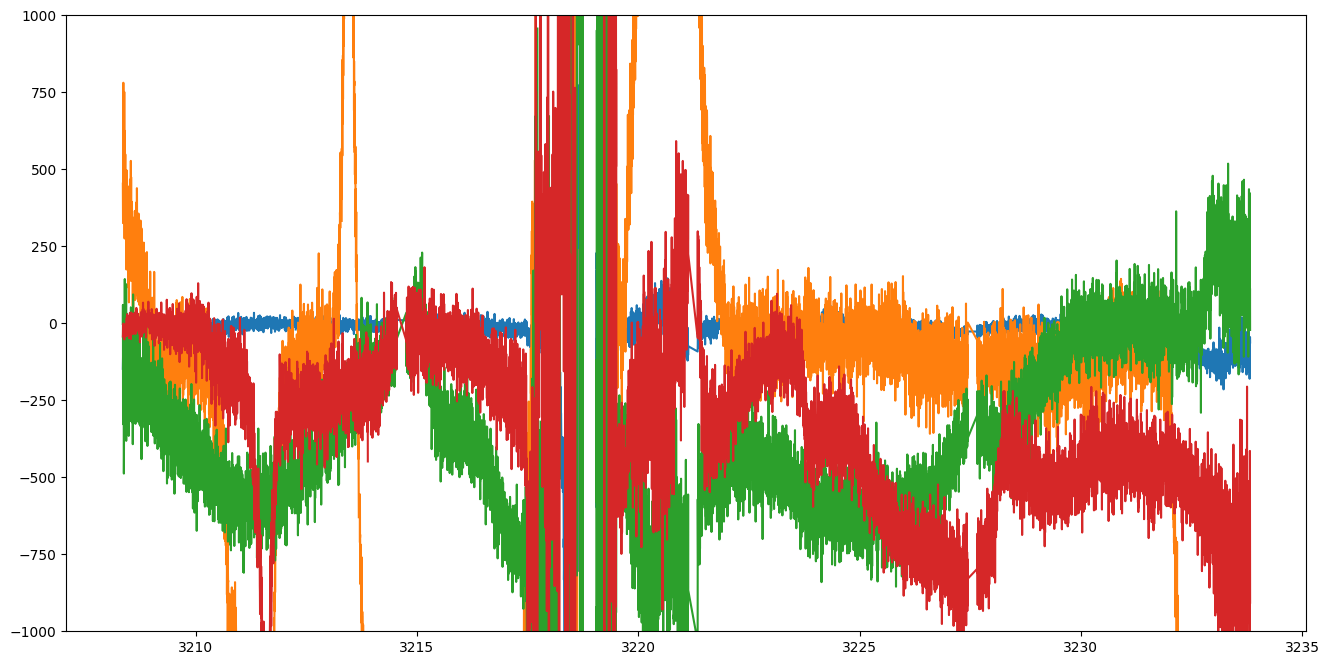

In [12]:
import matplotlib.pyplot as plt
from mklc import extract_positions, get_summed_fluxes

plt.figure(figsize=(16,8))
offsets = [(-20, 0), (20, 0), (0, -20), (0, 20)]
summed_offsets70 = []

for offset in offsets:
    summed_offset = get_summed_fluxes(data_stack_70, positions_all_70 - offset, 10)
    summed_offsets70.append(summed_offset)
    plt.plot(times_70, summed_offset)

plt.ylim(-1000, 1000)
plt.show()

In [7]:
pip install git+https://github.com/tessgi/tess-point.git


  Cloning https://github.com/tessgi/tess-point.git to /tmp/pip-req-build-wfkurw9b
  Running command git clone --filter=blob:none --quiet https://github.com/tessgi/tess-point.git /tmp/pip-req-build-wfkurw9b
  Resolved https://github.com/tessgi/tess-point.git to commit 387b4300f867bd2ab5b25a91b7464a9296e19c5a
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#data arrays